![image.png](https://i.imgur.com/a3uAqnb.png)

# **⚡ Wind Turbine Object Detection with RT-DETR**
In this lab, we will:
✅ **Use RT-DETR** for **wind turbine detection**  
✅ **Understand the dataset structure**  
✅ **Train a RT-DETR model**  
✅ **Evaluate the model on the validation set**  
✅ **Run inference on test images**  

---

## **1️⃣ Understanding the Dataset Structure**
The dataset follows the **RT-DETR format**, which consists of:
📂 **train/** → Training images & labels  
📂 **valid/** → Validation images & labels  
📂 **test/** → Test images (for inference)  
📜 **data.yaml** → Defines dataset paths & class names  

### **🔹 DETR Dataset Folder Structure**
```
drone_dataset/
│── train/
│   │── images/
│   │   ├── pic_031.jpg
│   │   ├── pic_032.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_031.txt
│   │   ├── pic_032.txt
│   │   ├── ...
│
│── valid/
│   │── images/
│   │   ├── pic_035.jpg
│   │   ├── pic_036.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_035.txt
│   │   ├── pic_036.txt
│   │   ├── ...
│
│── test/
│   │── images/
│   │   ├── pic_040.jpg
│   │   ├── pic_041.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_040.txt
│   │   ├── pic_041.txt
│   │   ├── ...
│
│── data.yaml
```
Each **image** has a **corresponding label** file with the **same name**, but a `.txt` extension.

---

## **2️⃣ What’s Inside a RT-DETR Label File?**
Each `.txt` file contains **annotations** in this format:

```
<class_id> <x_center> <y_center> <width> <height>
```

✅ **All values are normalized** between **0 and 1**  
✅ The **bounding box** is defined by its **center** and **size**  

### **🔹 Example (`pic_031.txt`)**
```
0 0.526 0.448 0.12 0.15
1 0.731 0.602 0.18 0.22
```
- **First column** → Class ID (`0` = cable tower, `1` = turbine)  
- **Rest** → Bounding box (normalized)  

---

## **3️⃣ Loading the Dataset**

In [1]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("kylegraupe/wind-turbine-image-dataset-for-computer-vision")

print("Path to dataset files:", path)

100%|██████████| 617M/617M [00:06<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12


In [2]:
# Load dataset configuration
dataset_path = path + "/data.yaml"

# Check dataset information
print(open(dataset_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['cable tower', 'turbine']

roboflow:
  workspace: kyle-graupe-jobhn
  project: wind-farms
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/kyle-graupe-jobhn/wind-farms/dataset/5


## **4️⃣ Training a DETR Model**
We will fine-tune a **pretrained DETR model**.

In [3]:
# Install Ultralytics library which has RT-DETR
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.7 MB/s eta 0:00:00


In [4]:
from ultralytics import RTDETR
import matplotlib.pyplot as plt
# loads the model
model = RTDETR("rtdetr-l.pt") # <-- 'l' stands for the large model, the downloaded weights are trained on COCO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Let's try to predict an image before training


image 1/1 /root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/test/images/windmill1_jpg.rf.35f47a69d0373596edb7578eea5151f6.jpg: 640x640 1 bench, 2 birds, 3 cows, 14.1ms
Speed: 7.9ms preprocess, 14.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


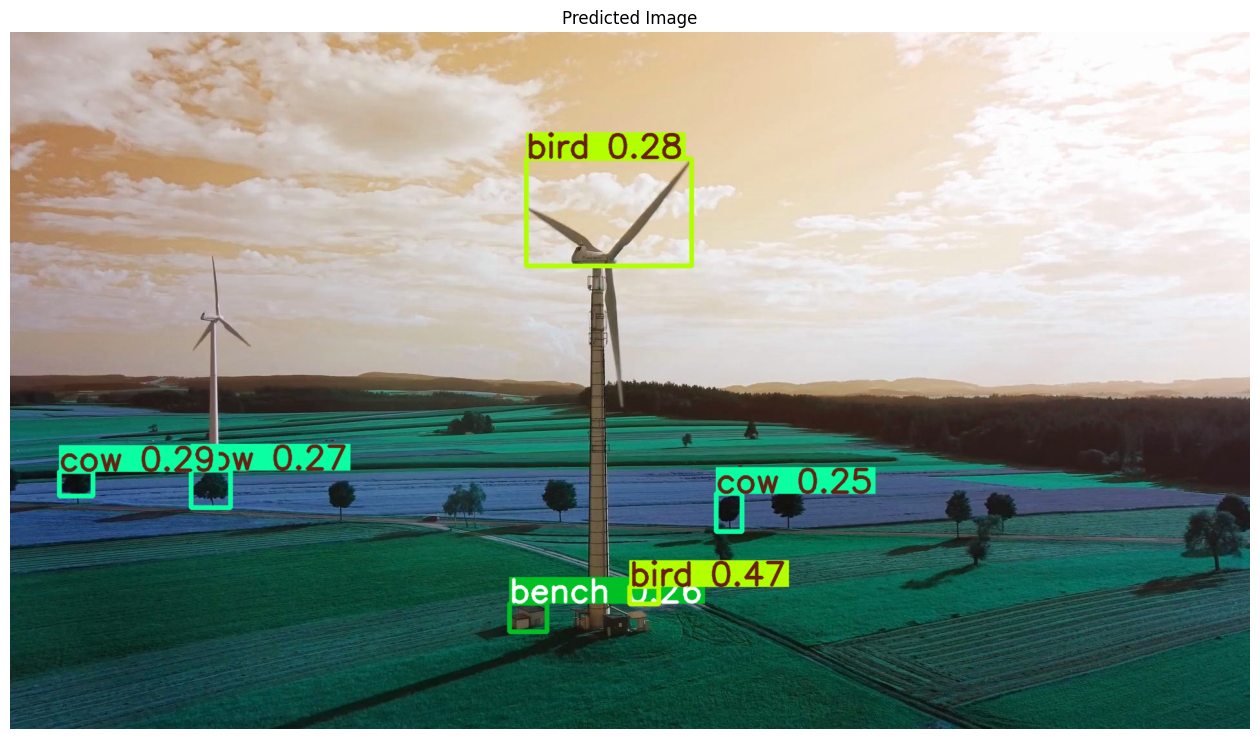

In [5]:
# Load an image and run inference
results = model(path + "/test/images/windmill1_jpg.rf.35f47a69d0373596edb7578eea5151f6.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()

#OMG, AI will take over the world.🫠

In [6]:
import os
import urllib.request
from ultralytics import RTDETR

# an image that has something on the COCO dataset
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image_name = "image_c59262.jpg"

print(f"Downloading COCO sample image as {image_name}...")
urllib.request.urlretrieve(image_url, image_name)
print("Download complete!")

Download complete!



image 1/1 /content/image_c59262.jpg: 640x640 2 cats, 1 couch, 2 beds, 2 remotes, 14.1ms
Speed: 1.2ms preprocess, 14.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


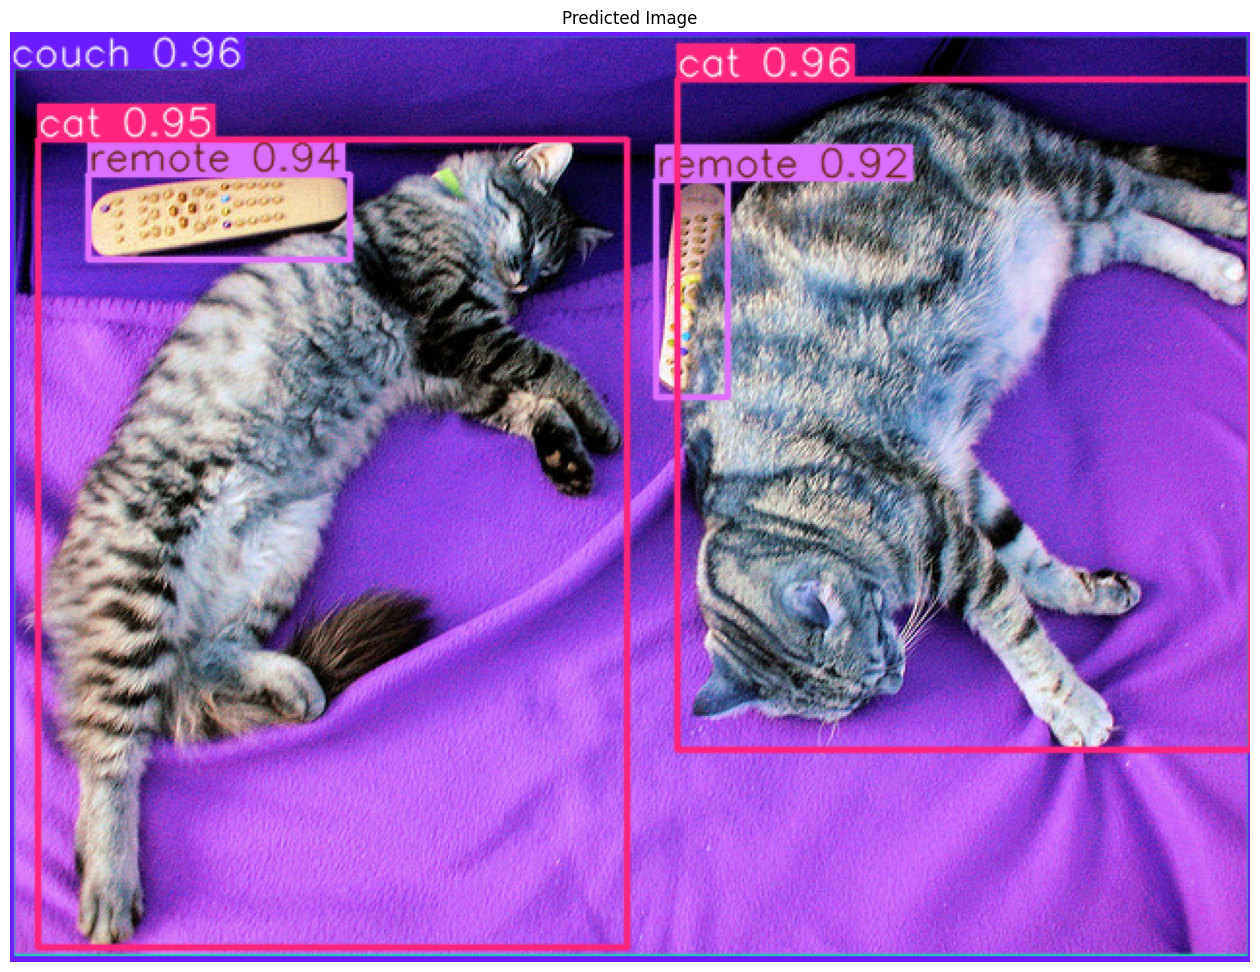

In [7]:
results = model(image_name)
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()


##



#### Nevermind, let's train it! 🚀

In [8]:
model.train(data=dataset_path, epochs=5, imgsz=640)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, m

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        1/5      41.1G      1.262     0.5286     0.4225         63       1280: 100% ━━━━━━━━━━━━ 166/166 1.9it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0it/s 2.7s
                   all        247       1562      0.693      0.141       0.11     0.0341

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
        2/5      41.1G     0.5868     0.5596     0.1004        282       1280: 0% ──────────── 0/166  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        2/5      41.1G     0.5422      0.445      0.096         55       1280: 100% ━━━━━━━━━━━━ 166/166 2.0it/s 1:22
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 11.1it/s 0.7s
                   all        247       1562      0.314      0.347      0.262       0.08

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
        3/5      41.1G      0.516     0.4342    0.06832        311       1280: 0% ──────────── 0/166  0.5s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        4/5      41.1G     0.3882     0.3547    0.04859         65       1280: 100% ━━━━━━━━━━━━ 166/166 2.0it/s 1:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 11.1it/s 0.7s
                   all        247       1562       0.46      0.366      0.343      0.107

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
        5/5      41.1G     0.3816       0.34    0.05498        271       1280: 0% ──────────── 0/166  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        5/5      41.1G     0.3538     0.3361    0.04371         56       1280: 100% ━━━━━━━━━━━━ 166/166 2.0it/s 1:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 11.0it/s 0.7s
                   all        247       1562      0.646       0.37      0.415      0.127

5 epochs completed in 0.117 hours.
Optimizer stripped from /content/runs/detect/train/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/detect/train/weights/best.pt, 66.2MB

Validating /content/runs/detect/train/weights/best.pt...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 7.4it/s 1.1s
                   all        247       1562      0.561      0.392      0.416      0.125
          

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fc2eeae84d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## **5️⃣ Evaluating the Model**
We use **mAP@0.5:0.95** to assess performance.

In [9]:
# Run validation
metrics = model.val(data=dataset_path)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7704.3±2921.4 MB/s, size: 153.2 KB)
val: Scanning /root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/valid/labels.cache... 247 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 247/247 172.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 10.2it/s 1.6s
                   all        247       1562      0.647      0.369      0.416      0.127
           cable tower          7         24      0.627      0.208      0.289     0.0632
               turbine        239       1538      0.668      0.529      0.542       0.19
Speed: 0.3ms preprocess, 4.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /co

## **6️⃣ Running Inference on Test Images**


In [24]:
# Ultralytics stores the best weights after training, we can load it later if we wanted
model = RTDETR("/content/runs/detect/train/weights/best.pt")


image 1/1 /root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/valid/images/windmill19_jpg.rf.f8224e52590245a427cbdef03e618c48.jpg: 640x640 4 turbines, 12.9ms
Speed: 1.3ms preprocess, 12.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-5


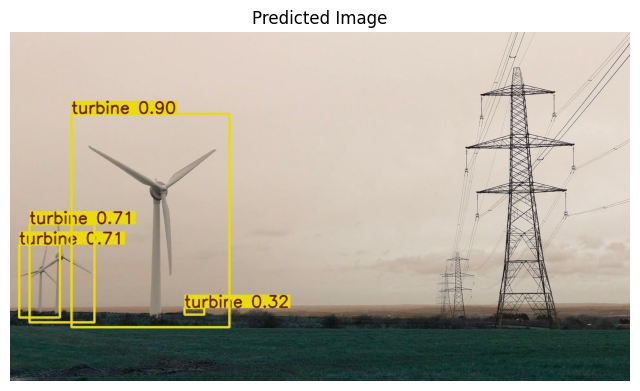

In [25]:
# Load an image and run inference
results = model(path + "/valid/images/windmill19_jpg.rf.f8224e52590245a427cbdef03e618c48.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(8, 8))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()


### 🚀 **Now you have a working DETR object detection pipeline for wind turbines!**
![image.png](https://i.imgur.com/rGGLEsK.png)

### Contributed by: Abdulrahman Alfrihidi & Muhannad

### BONUS !
you already studied Tensorflow lite, ultralytics allows you to export your model to a TFlite format, which you can drop in to your microcontroller with ease !

In [ ]:
# export the model to a tflite format with quantization of 8 bits
model.eval()
model.export(format="litert", quantize='int8', data=dataset_path)
# wait why did we need the data to export a model ... ?

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (AMD EPYC 9B45)
WARNING ⚠️ Head has no attribute 'end2end'.
WARNING ⚠️ LiteRT INT8 export does not support end2end models, disabling end2end branch.
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (63.1 MB)
LiteRT: collecting INT8 calibration images from 'data=/root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/data.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7441.0±4312.3 MB/s, size: 145.0 KB)
val: Scanning /root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/valid/labels.cache... 247 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 247/247 148.0Mit/s 0.0s
WARNING ⚠️ LiteRT: >300 images recommended for INT8 calibration, found 247 images.

LiteRT:

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:00) [ DONE] Write Model to /content/runs/detect/train/weights/best_int8.tflite (+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:472: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Generating Quantization Parameters::  34%|███▍      | 1028/3023 [00:00<00:00, 10277.14it/s]/usr/local/lib/python3.12/dist-packages/ai_edge_quantizer/algorithms/uniform_quantize/uniform_quantize_tensor.py:109: RuntimeWarning: invalid value encountered in cast
  return tensor.astype(qtype, copy=False)
Applying Transformations to tensors:: 100%|██████████| 3573/3573 [00:00<00:00, 14275.51it/s]


Model name: /content/runs/detect/train/weights/best_int8.tflite
Original model size: 123.86 MiB
Quantized model size: 33.87 MiB
Quantization Ratio: 0.27 (3.7x smaller)
Total time: 611.53 ms
LiteRT: export success ✅ 748.3s, saved as '/content/runs/detect/train/weights/best_int8.tflite' (33.9 MB)

Export complete (748.8s)
Results saved to /content/runs/detect/train/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best_int8.tflite imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best_int8.tflite imgsz=640 data=/root/.cache/kagglehub/datasets/kylegraupe/wind-turbine-image-dataset-for-computer-vision/versions/12/data.yaml  
Visualize:       https://netron.app


PosixPath('/content/runs/detect/train/weights/best_int8.tflite')

#### Model Deployment Summary

* **Model Parameters:** 31,987,850 (~32M)
* **Original Size:** 130 Mb
* **Quantized Size:** 35.5 Mb
* **Required RAM To Deploy:** ~36.5 Mb ~4x smaller size

**Note:** for smaller microcontrollers use smaller Ultralytics models.
> Now we can spot **Ali** everywhere !